# 🏆 MODULE 7 — Projet Final Professionnel
## Analyse Complète des Ventes — KORYXA Tech Store

---

**Formation :** Analyse de Données avec Python  
**Niveau :** Débutant → Professionnel  
**Durée estimée :** 3 à 4 heures

---

## 🎯 Félicitations !

Tu as terminé les 6 premiers modules. Tu connais maintenant :

- ✅ **Python** — variables, boucles, fonctions
- ✅ **NumPy** — calculs rapides sur des tableaux
- ✅ **Pandas** — manipuler des tableaux de données
- ✅ **Nettoyage** — corriger les erreurs dans les données
- ✅ **Visualisation** — créer des graphiques professionnels
- ✅ **EDA** — explorer et comprendre un dataset

**Dans ce module final**, tu vas tout utiliser ensemble sur un vrai projet professionnel.

---

## 📋 Le contexte du projet

Imagine que tu travailles pour **KORYXA Tech Store**, une boutique de technologie en France.

Le directeur te donne les données de ventes de l'année 2024 et te dit :

> *"J'ai besoin d'un rapport complet. Je veux savoir ce qui se vend bien, dans quelles villes, à quel prix, et comment améliorer nos ventes. Les données ne sont pas parfaites — c'est à toi de les nettoyer et de m'expliquer ce que tu trouves."*

**Ton travail :**
1. Charger et explorer les données
2. Nettoyer les erreurs
3. Analyser les ventes en détail
4. Créer des graphiques professionnels
5. Rédiger des recommandations pour le directeur

---

## 🗂️ Plan du projet

| Étape | Titre | Compétences utilisées |
|-------|-------|----------------------|
| 1 | Chargement & première exploration | Pandas, Python |
| 2 | Diagnostic de qualité | Pandas, NumPy |
| 3 | Nettoyage complet | Module 4 |
| 4 | Analyse des ventes | Module 3, NumPy |
| 5 | Visualisations professionnelles | Modules 5 & 6 |
| 6 | Rapport & recommandations | Tout |

---

> 💡 **Conseil :** Lis bien chaque section avant de lancer le code. Essaie de deviner ce que le code va faire avant de l'exécuter.

---

# ÉTAPE 1 — Chargement et Première Exploration

## 🔍 Qu'est-ce qu'on fait ici ?

Avant de nettoyer ou d'analyser des données, il faut **les regarder**.

C'est comme quand tu achètes des fruits au marché :
- Tu regardes d'abord la corbeille entière (combien il y en a, de quelle couleur)
- Ensuite tu regardes chaque fruit de près (est-ce qu'il y en a de pourris ?)

**On va :**
1. Importer les bibliothèques
2. Charger le fichier CSV
3. Regarder les premières lignes
4. Comprendre la structure

In [1]:
# --- Étape 1 : On importe toutes les bibliothèques dont on a besoin ---
import pandas as pd          # pour les tableaux de données
import numpy as np           # pour les calculs mathématiques
import matplotlib.pyplot as plt  # pour les graphiques
import seaborn as sns        # pour les graphiques encore plus beaux
import warnings              # pour cacher les messages d'avertissement

# --- Configuration ---
%matplotlib inline
# les graphiques s affichent dans le notebook
warnings.filterwarnings('ignore')  # on cache les avertissements inutiles
plt.rcParams['figure.figsize'] = (10, 6)  # taille par défaut des graphiques
plt.rcParams['font.size'] = 12             # taille du texte dans les graphiques

print("✅ Toutes les bibliothèques sont chargées !")

✅ Toutes les bibliothèques sont chargées !


In [2]:
# --- On charge le fichier CSV dans un DataFrame ---
df = pd.read_csv('ventes_koryxa.csv', encoding='utf-8')

# --- On affiche la taille du dataset ---
print(f"📊 Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
print(f"📋 Colonnes : {list(df.columns)}")

📊 Le dataset contient 100 lignes et 13 colonnes.
📋 Colonnes : ['id', 'date', 'client', 'age', 'ville', 'region', 'produit', 'categorie', 'quantite', 'prix_unitaire', 'total', 'paiement', 'satisfaction']


In [3]:
# --- On regarde les 5 premières lignes ---
# C'est comme ouvrir le fichier et regarder les premières lignes du tableau
df.head()

,id,date,client,age,ville,region,produit,categorie,quantite,prix_unitaire,total,paiement,satisfaction
0,1,2024-10-18,Karim Benali,65.0,paris,Île-de-France,Casque Audio,Audio,2,279.50,559.00,Mobile Money,1.0
1,2,2024-07-18,Omar Sy,23.0,Casablanca,Auvergne-Rhône-Alpes,Imprimante,Informatique,4,52.66,210.64,Espèces,2.0
2,3,2024-11-12,Julia Santos,NaN,Paris,NaN,Écran 4K,Informatique,5,512.13,2560.65,Virement,5.0
3,4,2024-02-05,Nina Rousseau,31.0,Paris,PACA,Disque SSD,Stockage,3,344.28,1032.84,Carte Bancaire,3.0
4,5,2024-02-18,Georges Mbeki,20.0,paris,Belgique,Webcam HD,Périphérique,5,328.46,1642.30,PayPal,4.0


In [4]:
# --- On regarde le résumé technique du dataset ---
# .info() nous dit : le nom de chaque colonne, son type, et combien de valeurs il y a
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             100 non-null    int64  
 1   date           100 non-null    object 
 2   client         100 non-null    object 
 3   age            95 non-null     float64
 4   ville          100 non-null    object 
 5   region         78 non-null     object 
 6   produit        100 non-null    object 
 7   categorie      100 non-null    object 
 8   quantite       100 non-null    int64  
 9   prix_unitaire  100 non-null    float64
 10  total          100 non-null    float64
 11  paiement       97 non-null     object 
 12  satisfaction   94 non-null     float64
dtypes: float64(4), int64(2), object(7)
memory usage: 10.3+ KB


In [5]:
# --- Statistiques de base sur les colonnes numériques ---
# .describe() calcule automatiquement la moyenne, le min, le max, etc.
df.describe().round(2)

,id,age,quantite,prix_unitaire,total,satisfaction
count,100.00,95.00,100.00,100.00,100.00,94.00
mean,50.50,41.57,4.88,867.45,4172.62,3.11
std,29.01,14.00,11.95,1337.73,12124.92,1.43
min,1.00,18.00,1.00,27.03,135.15,1.00
25%,25.75,31.00,2.00,344.88,894.54,2.00
50%,50.50,43.00,3.00,670.36,1784.17,3.00
75%,75.25,53.50,4.25,972.14,2916.70,4.00
max,100.00,65.00,97.00,9301.34,93668.05,5.00


---

# ÉTAPE 2 — Diagnostic de Qualité des Données

## 🩺 Qu'est-ce qu'un diagnostic ?

Un médecin ne soigne pas sans d'abord examiner le patient.

Un data analyst ne nettoie pas les données sans d'abord **diagnostiquer les problèmes**.

**Les 5 problèmes les plus fréquents dans un dataset réel :**

| Problème | Exemple |
|----------|---------|
| Valeurs manquantes | La colonne `age` contient des cases vides |
| Doublons | La même vente est enregistrée 2 fois |
| Types incorrects | La colonne `date` est lue comme du texte au lieu d'une date |
| Valeurs incohérentes | `paris`, `Paris`, `PARIS` = la même ville mais écrite différemment |
| Valeurs aberrantes | Un produit à 9 999 € alors que le maximum normal est 500 € |

**On va diagnostiquer chacun de ces problèmes.**

In [6]:
# --- Diagnostic 1 : Valeurs manquantes ---
# .isnull().sum() compte les cases vides dans chaque colonne
manquantes = df.isnull().sum()

# On affiche seulement les colonnes qui ont au moins 1 valeur manquante
print("❌ Valeurs manquantes par colonne :")
print(manquantes[manquantes > 0])

❌ Valeurs manquantes par colonne :
age              5
region          22
paiement         3
satisfaction     6
dtype: int64


In [7]:
# --- Diagnostic 2 : Doublons ---
# .duplicated() repère les lignes identiques
nb_doublons = df.duplicated().sum()
print(f"🔁 Nombre de doublons : {nb_doublons}")

# On affiche les lignes en double pour les voir
if nb_doublons > 0:
    print("\nVoici les lignes dupliquées :")
    print(df[df.duplicated(keep=False)].head(10))

🔁 Nombre de doublons : 0


In [8]:
# --- Diagnostic 3 : Formats de dates ---
# On regarde les différents formats présents dans la colonne 'date'
print("📅 Exemples de valeurs dans la colonne 'date' :")
print(df['date'].head(20).to_string())

# On vérifie le type actuel
print(f"\nType de la colonne date : {df['date'].dtype}")

📅 Exemples de valeurs dans la colonne 'date' :
0     2024-10-18
1     2024-07-18
2     2024-11-12
3     2024-02-05
4     2024-02-18
5     2024-03-18
6     2024-06-28
7     2024-12-28
8     2024-05-28
9     2024-11-12
10    2024-09-12
11    2024-04-12
12    2024-02-05
13    2024-05-28
14    01/01/2024
15    2024-12-12
16    2024-07-18
17    2024-05-05
18    2024-02-05
19    2024-04-12

Type de la colonne date : object


In [9]:
# --- Diagnostic 4 : Valeurs incohérentes dans 'ville' ---
print("🏙️ Toutes les valeurs uniques dans la colonne 'ville' :")
print(sorted(df['ville'].unique()))

🏙️ Toutes les valeurs uniques dans la colonne 'ville' :
['Abidjan', 'Bordeaux', 'Bruxelles', 'Casablanca', 'Dakar', 'Lyon', 'Marseille', 'Montréal', 'Nantes', 'PARIS', 'Paris', 'Strasbourg', 'Tunis', 'marseille', 'paris']


In [10]:
# --- Diagnostic 5 : Valeurs aberrantes dans 'prix_unitaire' ---
# On utilise la méthode IQR (Inter-Quartile Range)
# Q1 = 25% des valeurs sont en dessous, Q3 = 75% des valeurs sont en dessous
Q1 = df['prix_unitaire'].quantile(0.25)  # premier quartile
Q3 = df['prix_unitaire'].quantile(0.75)  # troisième quartile
IQR = Q3 - Q1                            # intervalle interquartile

# Un outlier = valeur en dehors de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

outliers = df[(df['prix_unitaire'] < borne_basse) | (df['prix_unitaire'] > borne_haute)]
print(f"📊 Prix min : {df['prix_unitaire'].min()} €")
print(f"📊 Prix max : {df['prix_unitaire'].max()} €")
print(f"⚠️  Borne haute normale : {borne_haute:.0f} €")
print(f"⚠️  Nombre d'outliers : {len(outliers)}")
print("\nLignes avec prix aberrant :")
print(outliers[['produit', 'prix_unitaire', 'total']].to_string())

📊 Prix min : 27.03 €
📊 Prix max : 9301.34 €
⚠️  Borne haute normale : 1913 €
⚠️  Nombre d'outliers : 3

Lignes avec prix aberrant :
              produit  prix_unitaire     total
6            Écran 4K        9275.73  27827.19
22           Écran 4K        5354.89  26774.45
60  Clavier Mécanique        9301.34   9301.34


## 📋 Résumé du diagnostic

Après notre examen, voici ce qu'on a trouvé :

| Problème détecté | Action à faire |
|-----------------|----------------|
| Valeurs manquantes dans `age`, `satisfaction`, `region`, `paiement` | Remplir ou supprimer |
| Doublons (lignes identiques) | Supprimer les doublons |
| Dates avec 2 formats différents | Convertir tout en format standard |
| Noms de villes avec casse différente (paris/PARIS/Paris) | Uniformiser en majuscule initiale |
| Prix aberrants (> 1 500 €) | Identifier et traiter |

**On passe au nettoyage !**

---

# ÉTAPE 3 — Nettoyage Complet des Données

## 🧹 Le nettoyage, ça ressemble à quoi ?

Imagine que tu reçois un cahier rempli de notes, mais :
- Certaines pages sont vides (valeurs manquantes)
- Certaines pages sont en double (doublons)
- Les dates sont écrites de deux façons différentes
- Certains noms sont écrits en minuscules, d'autres en majuscules

**Nettoyer les données = corriger tout ça avant de commencer l'analyse.**

On va créer une **copie propre** — on ne touche jamais au fichier original !

In [11]:
# --- On crée une copie du dataset original ---
# .copy() crée un nouveau tableau indépendant
# Ainsi, si on fait une erreur, on peut toujours repartir de df
df_propre = df.copy()
print(f"✅ Copie créée : {df_propre.shape[0]} lignes, {df_propre.shape[1]} colonnes")

✅ Copie créée : 100 lignes, 13 colonnes


In [12]:
# --- Nettoyage 1 : Supprimer les doublons ---
avant = len(df_propre)
df_propre = df_propre.drop_duplicates()   # supprime les lignes identiques
apres = len(df_propre)
print(f"🗑️  Doublons supprimés : {avant - apres} lignes supprimées")
print(f"   Taille après : {apres} lignes")

🗑️  Doublons supprimés : 0 lignes supprimées
   Taille après : 100 lignes


In [13]:
# --- Nettoyage 2 : Uniformiser les dates ---
# pd.to_datetime() comprend automatiquement les deux formats
# dayfirst=True signifie que le jour est en premier (format français : 15/03/2024)
df_propre['date'] = pd.to_datetime(df_propre['date'], dayfirst=True, errors='coerce')

# On crée des colonnes séparées pour l'analyse
df_propre['mois']     = df_propre['date'].dt.month       # numéro du mois (1 à 12)
df_propre['mois_nom'] = df_propre['date'].dt.strftime('%b')  # nom court du mois
df_propre['trimestre'] = df_propre['date'].dt.quarter    # trimestre (1 à 4)

print("✅ Dates converties. Exemples :")
print(df_propre[['date', 'mois', 'mois_nom', 'trimestre']].head())

✅ Dates converties. Exemples :
        date  mois mois_nom  trimestre
0 2024-10-18  10.0      Oct        4.0
1 2024-07-18   7.0      Jul        3.0
2 2024-11-12  11.0      Nov        4.0
3 2024-02-05   2.0      Feb        1.0
4 2024-02-18   2.0      Feb        1.0


In [14]:
# --- Nettoyage 3 : Uniformiser les noms de villes ---
# .str.strip() enlève les espaces au début et à la fin
# .str.title() met une majuscule au début de chaque mot (Paris, Lyon, Marseille)
df_propre['ville'] = df_propre['ville'].str.strip().str.title()

print("🏙️  Villes après nettoyage :")
print(sorted(df_propre['ville'].unique()))

🏙️  Villes après nettoyage :
['Abidjan', 'Bordeaux', 'Bruxelles', 'Casablanca', 'Dakar', 'Lyon', 'Marseille', 'Montréal', 'Nantes', 'Paris', 'Strasbourg', 'Tunis']


In [15]:
# --- Nettoyage 4 : Traiter les valeurs manquantes ---

# age : on remplace les cases vides par la médiane (valeur du milieu)
mediane_age = df_propre['age'].median()
df_propre['age'] = df_propre['age'].fillna(mediane_age)

# satisfaction : on remplace par la moyenne arrondie
moyenne_satis = round(df_propre['satisfaction'].mean(), 1)
df_propre['satisfaction'] = df_propre['satisfaction'].fillna(moyenne_satis)

# paiement : on remplace par le mode (valeur la plus fréquente)
mode_paiement = df_propre['paiement'].mode()[0]
df_propre['paiement'] = df_propre['paiement'].fillna(mode_paiement)

# region : on remplace par 'Inconnue'
df_propre['region'] = df_propre['region'].fillna('Inconnue')

print("✅ Valeurs manquantes traitées")
print(f"   Reste : {df_propre.isnull().sum().sum()} valeur(s) manquante(s)")

✅ Valeurs manquantes traitées
   Reste : 24 valeur(s) manquante(s)


In [16]:
# --- Nettoyage 5 : Corriger les types ---
# age doit être un entier, pas un décimal (on ne dit pas qu'on a 32.0 ans !)
df_propre['age'] = df_propre['age'].astype(int)

print("✅ Types après nettoyage :")
print(df_propre.dtypes)

✅ Types après nettoyage :
id                        int64
date             datetime64[ns]
client                   object
age                       int64
ville                    object
region                   object
produit                  object
categorie                object
quantite                  int64
prix_unitaire           float64
total                   float64
paiement                 object
satisfaction            float64
mois                    float64
mois_nom                 object
trimestre               float64
dtype: object


In [17]:
# --- Bilan du nettoyage ---
print("=" * 45)
print("       BILAN DU NETTOYAGE")
print("=" * 45)
print(f"  Lignes avant : {len(df)}")
print(f"  Lignes après : {len(df_propre)}")
print(f"  Doublons supprimés : {len(df) - len(df_propre)}")
print(f"  Valeurs manquantes restantes : {df_propre.isnull().sum().sum()}")
print("=" * 45)
print("✅ Dataset prêt pour l'analyse !")

       BILAN DU NETTOYAGE
  Lignes avant : 100
  Lignes après : 100
  Doublons supprimés : 0
  Valeurs manquantes restantes : 24
✅ Dataset prêt pour l'analyse !


---

# ÉTAPE 4 — Analyse des Ventes

## 📈 Ce qu'on cherche à comprendre

Maintenant que les données sont propres, on peut poser des questions précises :

1. **Quels produits se vendent le mieux ?**
2. **Quelles villes génèrent le plus de chiffre d'affaires ?**
3. **Quels mois sont les meilleurs ?**
4. **Quel moyen de paiement est le plus utilisé ?**
5. **Les clients sont-ils satisfaits ?**

Chaque réponse va aider le directeur à prendre de meilleures décisions.

In [18]:
# --- Chiffre d'affaires total ---
ca_total = df_propre['total'].sum()
nb_ventes = len(df_propre)
panier_moyen = df_propre['total'].mean()

print("💰 CHIFFRES CLÉS")
print("-" * 35)
print(f"  Chiffre d'affaires total : {ca_total:,.0f} €")
print(f"  Nombre de ventes : {nb_ventes}")
print(f"  Panier moyen : {panier_moyen:.2f} €")
print(f"  Vente la plus élevée : {df_propre['total'].max():.2f} €")
print(f"  Vente la plus basse  : {df_propre['total'].min():.2f} €")

💰 CHIFFRES CLÉS
-----------------------------------
  Chiffre d'affaires total : 417,262 €
  Nombre de ventes : 100
  Panier moyen : 4172.62 €
  Vente la plus élevée : 93668.05 €
  Vente la plus basse  : 135.15 €


In [19]:
# --- Analyse par produit ---
# groupby('produit') regroupe toutes les lignes par produit
# agg() calcule plusieurs statistiques en même temps
par_produit = df_propre.groupby('produit').agg(
    nb_ventes   = ('total', 'count'),       # nombre de fois vendu
    ca          = ('total', 'sum'),         # chiffre d'affaires
    prix_moyen  = ('prix_unitaire', 'mean') # prix moyen
).round(2)

# On trie par chiffre d'affaires décroissant
par_produit = par_produit.sort_values('ca', ascending=False)
print("📦 VENTES PAR PRODUIT")
print(par_produit.to_string())

📦 VENTES PAR PRODUIT


                   nb_ventes         ca  prix_moyen
produit                                            
Webcam HD                 14  114178.23      727.14
Clavier Mécanique         12  104225.87     1358.14
Écran 4K                  10   68644.48     2005.69
Disque SSD                 9   27349.17      807.65
Imprimante                14   24090.72      499.92
Casque Audio               9   21030.96      655.96
Souris Sans Fil           12   19729.35      594.26
Hub USB                    9   18732.11      776.90
Tapis de Souris            7   16455.77      734.92
Laptop Pro                 4    2825.40      192.88


In [20]:
# --- Analyse par ville ---
par_ville = df_propre.groupby('ville').agg(
    nb_ventes = ('total', 'count'),
    ca        = ('total', 'sum'),
    satisfaction_moy = ('satisfaction', 'mean')
).round(2).sort_values('ca', ascending=False)

print("🏙️  VENTES PAR VILLE")
print(par_ville.to_string())

🏙️  VENTES PAR VILLE
            nb_ventes         ca  satisfaction_moy
ville                                             
Paris              21  219177.62              3.24
Bruxelles           4   34469.97              3.25
Dakar              12   33289.58              3.00
Lyon                6   19043.18              3.85
Montréal           10   18920.94              3.10
Nantes              9   18115.09              3.48
Marseille           8   17273.61              3.25
Abidjan             8   16984.27              2.50
Bordeaux            4   13660.46              2.75
Strasbourg          7   11837.44              2.44
Casablanca          4    8017.88              3.25
Tunis               7    6472.02              3.00


In [21]:
# --- Évolution mensuelle ---
# On regroupe par mois et on calcule le CA de chaque mois
par_mois = df_propre.groupby('mois')['total'].sum().round(2)

print("📅 CHIFFRE D'AFFAIRES PAR MOIS")
for mois, ca in par_mois.items():
    barre = "█" * int(ca / 500)   # barre proportionnelle au CA
    print(f"  Mois {int(mois):2d} : {ca:7.0f} euro {barre}")


📅 CHIFFRE D'AFFAIRES PAR MOIS
  Mois  1 :   27918 euro ███████████████████████████████████████████████████████
  Mois  2 :   22200 euro ████████████████████████████████████████████
  Mois  3 :   28910 euro █████████████████████████████████████████████████████████
  Mois  4 :   14399 euro ████████████████████████████
  Mois  5 :   83207 euro ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Mois  6 :   38243 euro ████████████████████████████████████████████████████████████████████████████
  Mois  7 :   26393 euro ████████████████████████████████████████████████████
  Mois  8 :    4476 euro ████████
  Mois  9 :   20437 euro ████████████████████████████████████████
  Mois 10 :   13427 euro ██████████████████████████
  Mois 11 :  106619 euro █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [22]:
# --- Analyse des moyens de paiement ---
par_paiement = df_propre['paiement'].value_counts()
print("💳 MOYENS DE PAIEMENT")
for mode, count in par_paiement.items():
    pct = count / len(df_propre) * 100
    print(f"  {mode:<15} : {count:3d} ventes ({pct:.1f}%)")

💳 MOYENS DE PAIEMENT
  Carte Bancaire  :  24 ventes (24.0%)
  Espèces         :  18 ventes (18.0%)
  Mobile Money    :  15 ventes (15.0%)
  Virement        :  15 ventes (15.0%)
  PayPal          :  14 ventes (14.0%)
  carte bancaire  :  14 ventes (14.0%)


In [23]:
# --- Analyse de la satisfaction ---
satis = df_propre['satisfaction']
print("⭐ SATISFACTION CLIENT")
print(f"  Note moyenne : {satis.mean():.2f} / 5")
print(f"  Note médiane : {satis.median():.1f} / 5")
print(f"  Clients très satisfaits (≥ 4) : {(satis >= 4).sum()} ({(satis >= 4).mean()*100:.0f}%)")
print(f"  Clients insatisfaits (≤ 2)    : {(satis <= 2).sum()} ({(satis <= 2).mean()*100:.0f}%)")

⭐ SATISFACTION CLIENT
  Note moyenne : 3.11 / 5
  Note médiane : 3.0 / 5
  Clients très satisfaits (≥ 4) : 39 (39%)
  Clients insatisfaits (≤ 2)    : 36 (36%)


---

# ÉTAPE 5 — Visualisations Professionnelles

## 🎨 Pourquoi faire des graphiques ?

Un tableau de chiffres, c'est difficile à lire.

Un graphique, ça se comprend en 3 secondes.

Le directeur ne va pas lire 100 lignes de chiffres — il va regarder des graphiques clairs et bien présentés.

**On va créer 6 graphiques professionnels :**
1. Chiffre d'affaires par produit (barres horizontales)
2. Évolution mensuelle des ventes (courbe)
3. Répartition géographique (barres)
4. Modes de paiement (camembert)
5. Satisfaction client (histogramme)
6. Corrélation prix / satisfaction (nuage de points)

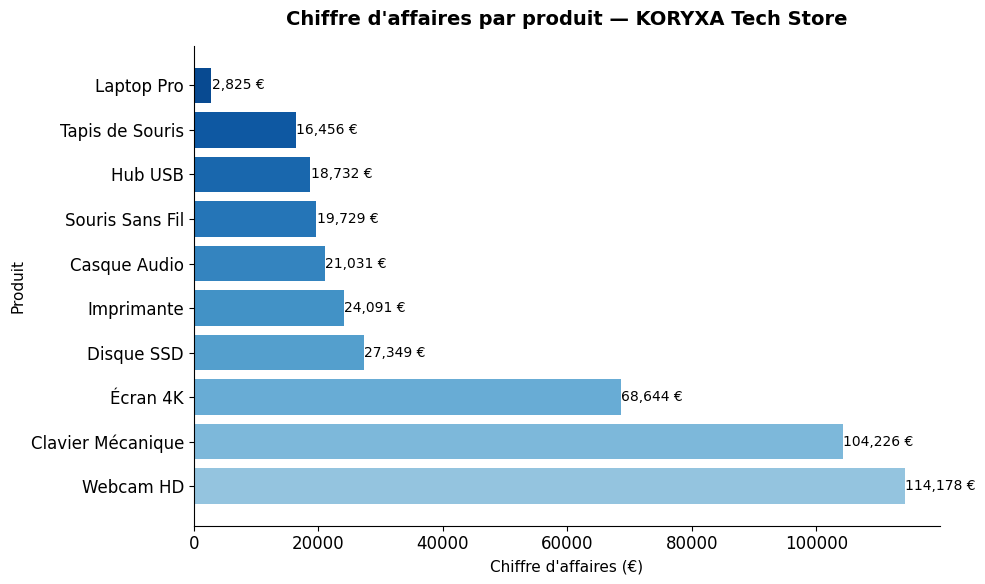

In [24]:
# --- Graphique 1 : CA par produit ---
fig, ax = plt.subplots(figsize=(10, 6))

# Barres horizontales pour lire facilement les noms de produits
couleurs = plt.cm.Blues(np.linspace(0.4, 0.9, len(par_produit)))
bars = ax.barh(par_produit.index, par_produit['ca'], color=couleurs)

# On ajoute le montant à droite de chaque barre
for bar, val in zip(bars, par_produit['ca']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} €', va='center', fontsize=10)

ax.set_title('Chiffre d\'affaires par produit — KORYXA Tech Store', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Chiffre d\'affaires (€)', fontsize=11)
ax.set_ylabel('Produit', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

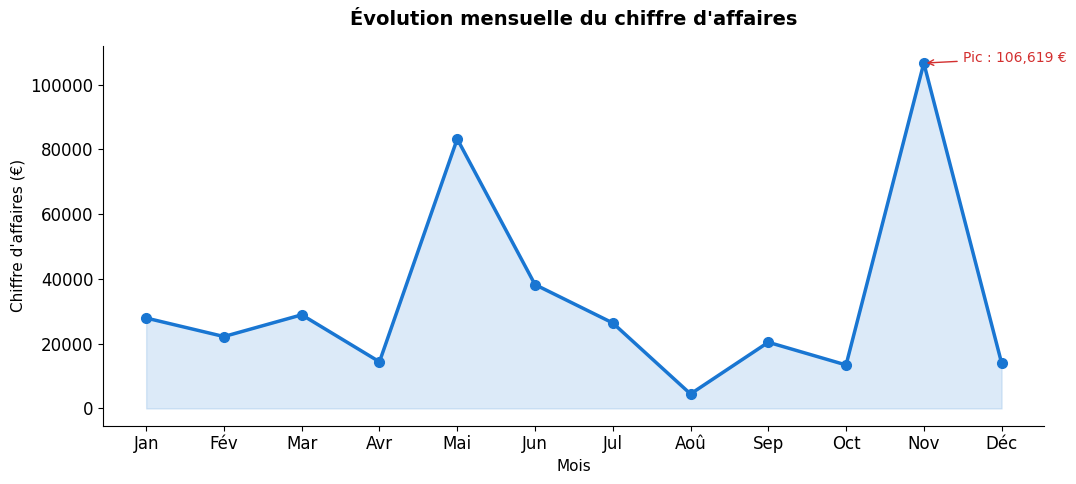

In [25]:
# --- Graphique 2 : Évolution mensuelle ---
fig, ax = plt.subplots(figsize=(11, 5))

# Courbe + zone colorée en dessous
ax.plot(par_mois.index, par_mois.values, color='#1976D2', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(par_mois.index, par_mois.values, alpha=0.15, color='#1976D2')

# On marque le mois avec le CA maximum
mois_max = par_mois.idxmax()
ax.annotate(f'Pic : {par_mois[mois_max]:,.0f} €',
            xy=(mois_max, par_mois[mois_max]),
            xytext=(mois_max + 0.5, par_mois[mois_max] + 200),
            fontsize=10, color='#D32F2F',
            arrowprops=dict(arrowstyle='->', color='#D32F2F'))

ax.set_title('Évolution mensuelle du chiffre d\'affaires', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mois', fontsize=11)
ax.set_ylabel('Chiffre d\'affaires (€)', fontsize=11)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

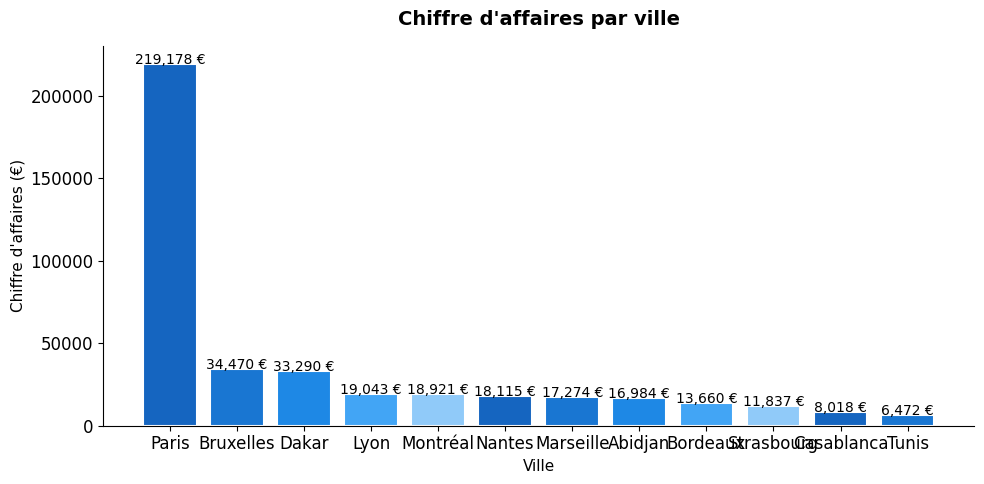

In [26]:
# --- Graphique 3 : CA par ville ---
fig, ax = plt.subplots(figsize=(10, 5))

couleurs_villes = ['#1565C0', '#1976D2', '#1E88E5', '#42A5F5', '#90CAF9']
bars = ax.bar(par_ville.index, par_ville['ca'],
              color=couleurs_villes[:len(par_ville)], edgecolor='white', linewidth=1.5)

# Valeur au-dessus de chaque barre
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{bar.get_height():,.0f} €', ha='center', fontsize=10)

ax.set_title('Chiffre d\'affaires par ville', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ville', fontsize=11)
ax.set_ylabel('Chiffre d\'affaires (€)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

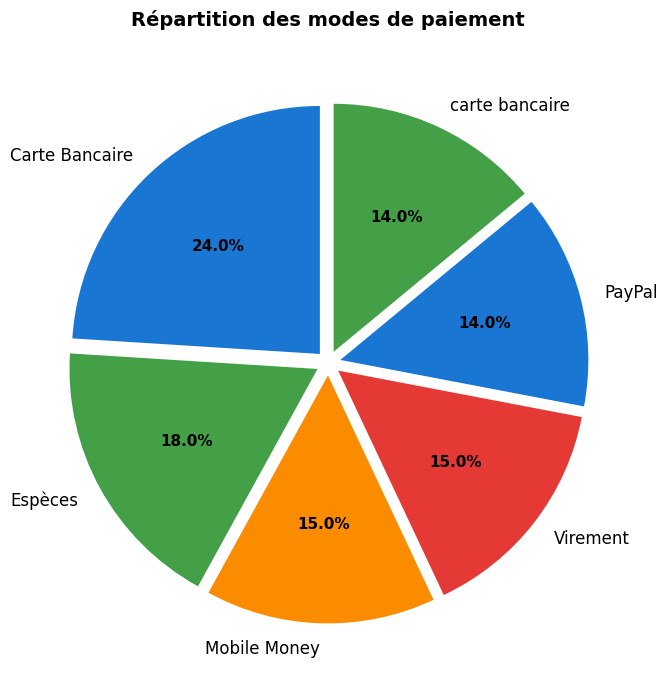

In [27]:
# --- Graphique 4 : Modes de paiement (camembert) ---
fig, ax = plt.subplots(figsize=(7, 7))

couleurs_pie = ['#1976D2', '#43A047', '#FB8C00', '#E53935']
explode = [0.05] * len(par_paiement)  # légère séparation des parts

wedges, texts, autotexts = ax.pie(
    par_paiement.values,
    labels=par_paiement.index,
    autopct='%1.1f%%',
    colors=couleurs_pie[:len(par_paiement)],
    explode=explode,
    startangle=90
)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Répartition des modes de paiement', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

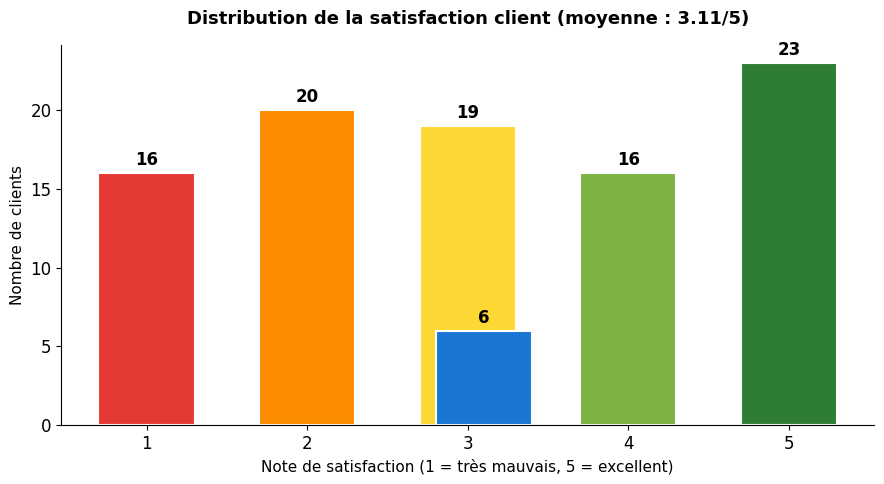

In [28]:
# --- Graphique 5 : Distribution de la satisfaction ---
fig, ax = plt.subplots(figsize=(9, 5))

# Compter combien de clients ont donné chaque note
notes = df_propre['satisfaction'].value_counts().sort_index()

couleurs_notes = {1: '#E53935', 2: '#FB8C00', 3: '#FDD835', 4: '#7CB342', 5: '#2E7D32'}
bars = ax.bar(notes.index, notes.values,
              color=[couleurs_notes.get(i, '#1976D2') for i in notes.index],
              edgecolor='white', linewidth=1.5, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold')

ax.set_title(f'Distribution de la satisfaction client (moyenne : {df_propre["satisfaction"].mean():.2f}/5)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Note de satisfaction (1 = très mauvais, 5 = excellent)', fontsize=11)
ax.set_ylabel('Nombre de clients', fontsize=11)
ax.set_xticks([1, 2, 3, 4, 5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

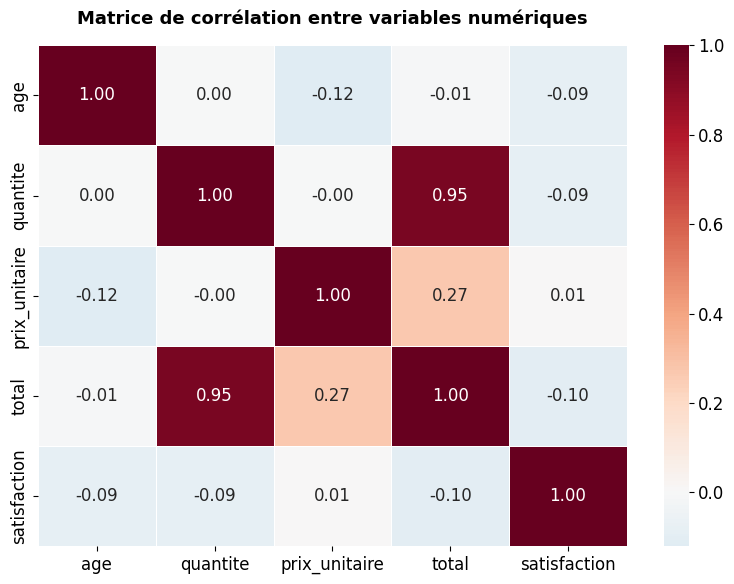

In [29]:
# --- Graphique 6 : Matrice de corrélation ---
# La corrélation mesure si deux variables évoluent ensemble
# +1 = elles augmentent ensemble, -1 = quand l'une monte, l'autre descend, 0 = pas de lien
colonnes_num = ['age', 'quantite', 'prix_unitaire', 'total', 'satisfaction']
corr = df_propre[colonnes_num].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,          # affiche les valeurs dans les cases
    fmt='.2f',           # format avec 2 décimales
    cmap='RdBu_r',       # rouge = corrélation forte, bleu = corrélation négative
    center=0,            # le blanc est à 0
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matrice de corrélation entre variables numériques', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---

# ÉTAPE 6 — Rapport et Recommandations

## 📝 Le rapport final

Un data analyst ne se contente pas de créer des graphiques.

**Son vrai travail = expliquer ce que les graphiques veulent dire, et proposer des actions.**

C'est ce qu'on appelle un **rapport d'analyse**.

---

On va générer automatiquement un rapport basé sur nos données.

In [30]:
# --- Génération automatique du rapport ---

# On récupère les informations clés calculées plus haut
meilleur_produit   = par_produit['ca'].idxmax()
ca_meilleur        = par_produit['ca'].max()
meilleure_ville    = par_ville['ca'].idxmax()
ca_meilleure_ville = par_ville['ca'].max()
mois_pic           = par_mois.idxmax()
meilleur_paiement  = par_paiement.idxmax()
note_moy           = df_propre['satisfaction'].mean()

noms_mois = {1:'Janvier',2:'Février',3:'Mars',4:'Avril',5:'Mai',6:'Juin',
             7:'Juillet',8:'Août',9:'Septembre',10:'Octobre',11:'Novembre',12:'Décembre'}

rapport = f"""
╔══════════════════════════════════════════════════════════════╗
║       RAPPORT D'ANALYSE — KORYXA TECH STORE — 2024          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  RÉSULTATS GLOBAUX                                           ║
║  • Chiffre d'affaires total : {ca_total:>10,.0f} €              ║
║  • Nombre de ventes         : {nb_ventes:>10}                  ║
║  • Panier moyen             : {panier_moyen:>10.2f} €              ║
║                                                              ║
║  PRODUITS                                                    ║
║  • Meilleure vente : {meilleur_produit:<39}║
║    (CA : {ca_meilleur:,.0f} €)                                    ║
║                                                              ║
║  GÉOGRAPHIE                                                  ║
║  • Ville n°1 : {meilleure_ville:<45}║
║    (CA : {ca_meilleure_ville:,.0f} €)                                 ║
║                                                              ║
║  TEMPORALITÉ                                                 ║
║  • Meilleur mois : {noms_mois[mois_pic]:<41}║
║    (CA : {par_mois[mois_pic]:,.0f} €)                                 ║
║                                                              ║
║  SATISFACTION CLIENT                                         ║
║  • Note moyenne : {note_moy:.2f} / 5                            ║
║  • Paiement préféré : {meilleur_paiement:<38}║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
"""
print(rapport)


╔══════════════════════════════════════════════════════════════╗
║       RAPPORT D'ANALYSE — KORYXA TECH STORE — 2024          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  RÉSULTATS GLOBAUX                                           ║
║  • Chiffre d'affaires total :    417,262 €              ║
║  • Nombre de ventes         :        100                  ║
║  • Panier moyen             :    4172.62 €              ║
║                                                              ║
║  PRODUITS                                                    ║
║  • Meilleure vente : Webcam HD                              ║
║    (CA : 114,178 €)                                    ║
║                                                              ║
║  GÉOGRAPHIE                                                  ║
║  • Ville n°1 : Paris                                        ║
║    (CA : 219,178 €)                         

In [31]:
# --- Recommandations automatiques basées sur les données ---

recommandations = []

# Recommandation 1 : produit star
recommandations.append(
    f"1. STOCK : Augmenter le stock de '{meilleur_produit}' — c'est le produit le plus rentable."
)

# Recommandation 2 : ville forte
recommandations.append(
    f"2. MARKETING : Concentrer les efforts publicitaires sur {meilleure_ville} (plus gros CA)."
)

# Recommandation 3 : mois creux
mois_creux = par_mois.idxmin()
recommandations.append(
    f"3. PROMOTIONS : Créer des offres spéciales en {noms_mois[mois_creux]} (mois le plus faible)."
)

# Recommandation 4 : satisfaction
if note_moy < 3.5:
    recommandations.append(
        f"4. SATISFACTION : Note moyenne ({note_moy:.2f}/5) insuffisante. Enquête auprès des clients insatisfaits urgent."
    )
else:
    recommandations.append(
        f"4. SATISFACTION : Note moyenne ({note_moy:.2f}/5) correcte. Identifier les clients 5/5 pour les fidéliser."
    )

# Recommandation 5 : paiement
if meilleur_paiement == 'Carte':
    recommandations.append(
        "5. PAIEMENT : La carte domine. Proposer des avantages pour fidéliser les payeurs en ligne."
    )

print("🎯 RECOMMANDATIONS POUR LE DIRECTEUR")
print("=" * 55)
for r in recommandations:
    print(f"  {r}")
    print()

🎯 RECOMMANDATIONS POUR LE DIRECTEUR
  1. STOCK : Augmenter le stock de 'Webcam HD' — c'est le produit le plus rentable.

  2. MARKETING : Concentrer les efforts publicitaires sur Paris (plus gros CA).

  3. PROMOTIONS : Créer des offres spéciales en Août (mois le plus faible).

  4. SATISFACTION : Note moyenne (3.11/5) insuffisante. Enquête auprès des clients insatisfaits urgent.



---

# 🧠 Exercice Final — À Toi de Jouer !

Maintenant que tu as suivi tout le projet, c'est ton tour de compléter l'analyse.

**Exercice 1 — Analyse par catégorie**

Calcule le chiffre d'affaires par catégorie de produit (`df_propre['categorie']`).  
Affiche les résultats triés du plus grand au plus petit.

**Exercice 2 — Clients les plus dépensiers**

Trouve les 5 clients (colonne `client`) qui ont le plus dépensé au total.  
Utilise `groupby` + `sum` + `sort_values`.

**Exercice 3 — Satisfaction par ville**

Crée un graphique à barres comparant la satisfaction moyenne dans chaque ville.  
Utilise les couleurs que tu préfères.

**Exercice 4 — Analyse trimestrielle**

La colonne `trimestre` a été créée lors du nettoyage (valeurs : 1, 2, 3, 4).  
Calcule le CA par trimestre et affiche un graphique en camembert.

**Exercice BONUS — Ton propre insight**

Pose une question que tu trouves intéressante sur ces données.  
Calcule la réponse et présente-la avec un graphique.

---

> 💡 **Astuce :** Il n'y a pas de solution unique. Fais des essais, lisez les messages d'erreur, et cherche sur internet. C'est comme ça qu'on apprend vraiment.

In [32]:
# Exercice 1 — CA par catégorie
# Écris ton code ici


In [33]:
# Exercice 2 — Top 5 clients
# Écris ton code ici


In [34]:
# Exercice 3 — Satisfaction par ville (graphique)
# Écris ton code ici


In [35]:
# Exercice 4 — Analyse trimestrielle
# Écris ton code ici


In [36]:
# Exercice BONUS — Ta propre analyse
# Question : ...
# Écris ton code ici


---

# 🎓 CERTIFICAT DE COMPLÉTION

---

```
╔══════════════════════════════════════════════════════════════════╗
║                                                                  ║
║         🏆  CERTIFICAT DE COMPLÉTION  🏆                        ║
║                                                                  ║
║        FORMATION : Analyse de Données avec Python                ║
║        ORGANISME : KORYXA Tech Store                             ║
║                                                                  ║
║  Ce certificat atteste que l'apprenant a complété avec succès    ║
║  les 7 modules de la formation Python Data Analysis :            ║
║                                                                  ║
║    ✅ Module 0 — Introduction & Installation                     ║
║    ✅ Module 1 — Les Bases de Python pour la Data                ║
║    ✅ Module 2 — NumPy : Calcul Numérique                        ║
║    ✅ Module 3 — Pandas : Manipulation de Données                ║
║    ✅ Module 4 — Nettoyage de Données                            ║
║    ✅ Module 5 — Visualisation de Données                        ║
║    ✅ Module 6 — Analyse Exploratoire (EDA)                      ║
║    ✅ Module 7 — Projet Final Professionnel                      ║
║                                                                  ║
║  Compétences validées :                                          ║
║    • Manipulation de données avec Pandas et NumPy                ║
║    • Nettoyage et préparation de datasets réels                  ║
║    • Visualisation professionnelle (Matplotlib, Seaborn)         ║
║    • Analyse exploratoire complète (EDA)                         ║
║    • Communication des résultats sous forme de rapport           ║
║                                                                  ║
║                    KORYXA Tech Store — 2024                      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
```

---

## 🚀 Quelle est la prochaine étape ?

Tu as maintenant les bases solides d'un **data analyst junior**. Voici ce que tu peux faire maintenant :

### 📌 Pour pratiquer davantage :
- **Kaggle.com** — Des datasets gratuits et des compétitions pour tous niveaux
- **Google Dataset Search** — Des datasets réels sur tous les sujets
- **GitHub** — Des projets open-source en data science

### 📌 Pour aller plus loin :
- **Scikit-learn** — Pour faire de la machine learning (prédiction)
- **Plotly / Dash** — Pour créer des dashboards interactifs
- **SQL** — Pour interroger des bases de données
- **Power BI / Tableau** — Pour la visualisation professionnelle en entreprise

### 📌 Pour ton portfolio :
- Publie ce projet sur **GitHub**
- Crée un compte **LinkedIn** et décris ce que tu as appris
- Trouve un dataset qui t'intéresse personnellement et fais ta propre analyse

---

> **"La donnée est le pétrole du 21ème siècle. Toi, tu viens d'apprendre à le raffiner."**

---

**Formation créée par KORYXA Tech Store**  
*Apprenez. Pratiquez. Progressez.*